In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
from lobster import *

In [3]:
ticker = "INTC"
message_path  = f"data/LOBSTER_SampleFile_{ticker}_2012-06-21_5/{ticker}_2012-06-21_34200000_57600000_message_5.csv"
orderbook_path = f"data/LOBSTER_SampleFile_{ticker}_2012-06-21_5/{ticker}_2012-06-21_34200000_57600000_orderbook_5.csv"
levels=5
K=5

msg, ob, qr, df = load_lobster_data(message_path, orderbook_path, levels=levels, K=K)
#[["type", "lvl", "size", "P_1", "Q_1", "P_-1", "Q_-1", "P_2", "Q_2", "P_-2", "Q_-2", "P_3", "Q_3", "P_-3", "Q_-3", "P_4", "Q_4", "P_-4", "Q_-4", "P_5", "Q_5", "P_-5", "Q_-5"]]
df

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.006241,0.006241,0.006241,L,275200,1,100,275150.0,275200.0,166,...,200,275500.0,0,274800.0,661,275600.0,100,274700.0,300,1
1,34200.006462,0.000221,0.000221,L,275500,4,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
2,34200.048864,0.042402,0.042623,C,275000,-2,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
3,34200.048883,0.000020,0.042642,C,275100,-1,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
4,34200.048989,0.000106,0.000125,L,275000,-2,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580346,57599.860444,0.011408,0.011408,C,267200,1,34600,267150.0,267200.0,88104,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157
580347,57599.860635,0.000191,0.223738,L,267000,-2,16600,267150.0,267200.0,88104,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157
580348,57599.870108,0.009473,0.249387,C,267400,3,600,267150.0,267200.0,88104,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157
580349,57599.939645,0.069536,0.079201,L,267200,1,100,267150.0,267200.0,88204,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157


In [4]:
table1 = make_descriptive_table(df, K=5)
table1

,#L (×10^3),#C (×10^3),#M (×10^2),AES,AIT (ms)
Level,,,,,
1,197.19,162.42,324.82,483.88,119.1
2,40.20,59.75,0.00,441.55,462.3
3,22.71,22.55,0.00,451.23,1004.4
4,13.23,11.88,0.00,475.07,1672.0
5,9.50,8.44,0.00,596.93,2263.0


In [5]:
aes = compute_aes_by_level(df, K=5, lvl_col="lvl", size_col="size") 
df_norm = normalize_by_aes(df, aes=aes, K=5)
df_norm.head(10)

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.006241,0.006241,0.006241,L,275200,1,1,275150.0,275200.0,1,...,1,275500.0,0,274800.0,2,275600.0,1,274700.0,1,1
1,34200.006462,0.000221,0.000221,L,275500,4,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
2,34200.048864,0.042402,0.042623,C,275000,-2,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
3,34200.048883,0.000020,0.042642,C,275100,-1,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
4,34200.048989,0.000106,0.000125,L,275000,-2,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
5,34200.049011,0.000022,0.042770,L,274900,-3,2,275150.0,275200.0,1,...,2,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
6,34200.049078,0.000068,0.042837,L,274800,-4,2,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,1,1
7,34200.049110,0.000032,0.042869,L,274700,-5,1,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,2,1
8,34200.049301,0.000190,0.000311,L,275000,-2,1,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,2,1
9,34200.211338,0.162038,0.205097,M,275200,1,1,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,2,1


### Training DataFrame: ###
From where we will extract our different state vectors $x_k$.

In [6]:
df_train = df_norm.copy()

groups = df_train.groupby("lvl") # df_lvl_1 = groups.get_group(1)
level_dfs = {lvl: group for lvl, group in groups}

lvl = 1
df = level_dfs[lvl].copy()

# 1) Event ID 
event_map = {"L": 0, "C": 1, "M": 2}
df["event_id"] = df["type"].map(event_map)

# 2) Hour of last event
df["hour_last_event"] = df["time"].shift(1) // 3600

# 3) Last event ID
df["last_event_id"] = df["event_id"].shift(1)

# 4) Queue before event
df["q_before_event"] = df[f"Q_{lvl}"].shift(1)

# Formatting the data for embedding
df = df.dropna().reset_index(drop=True)
# Hour as unique numbers from 0 to 7
df["hour_last_event"] = df["hour_last_event"].astype("int64")
hour_map = {h: i for i, h in enumerate(sorted(df["hour_last_event"].unique()))}
df["hour_last_event"] = df["hour_last_event"].map(hour_map)
df["last_event_id"] = df["last_event_id"].astype("int64")
df["q_before_event"] = df["q_before_event"].astype("int64")

df[["event_id", "dtk", "q_before_event", "hour_last_event", "last_event_id"]]

,event_id,dtk,q_before_event,hour_last_event,last_event_id
0,2,0.162038,1,0,0
1,2,0.000000,1,0,2
2,2,0.000000,0,0,2
3,0,0.000039,0,0,2
4,2,0.021914,1,0,0
...,...,...,...,...,...
181135,1,0.000052,256,6,1
181136,1,0.197321,253,6,1
181137,0,0.014818,252,6,1
181138,1,0.011408,254,6,0


In [7]:
df_train = df_norm.copy()

# 1) event id
event_map = {"L": 0, "C": 1, "M": 2}
df_train["event_id"] = df_train["type"].map(event_map).astype("int64")

# 2) hour of last event at the same level
df_train["hour_last_event"] = (df_train.groupby("lvl")["time"].shift(1) // 3600)

# 3) last event id at the same level
df_train["last_event_id"] = (df_train.groupby("lvl")["event_id"].shift(1))

# 4) pre-event queues within each constant-pref segment
def _q_event_row(row):
    idx = row.name
    if idx == 0:
        return np.nan 
    prev = df_train.iloc[idx - 1]  # previous row
    l = int(row["lvl"])
    if l == 0:
        return np.nan
    return prev[f"Q_{l}"]
df_train["q_before_event"] = df_train.apply(_q_event_row, axis=1).astype("float64")

# 5) clean dataframe of nan
df_train = df_train.dropna().reset_index(drop=True)
df_train[["q_before_event", "last_event_id"]] = df_train[["q_before_event", "last_event_id"]].astype("int64")
hour_map = {h: i for i, h in enumerate(sorted(df_train["hour_last_event"].unique()))}
df_train["hour_last_event"] = df_train["hour_last_event"].map(hour_map)

# 5) keep only what you need
df_train = df_train[["event_id", "lvl", "size", "dtk_l", "q_before_event", "last_event_id", "hour_last_event"]].copy()
df_train[df_train["lvl"]==1]

,event_id,lvl,size,dtk_l,q_before_event,last_event_id,hour_last_event
2,2,1,1,0.205097,1,0,0
3,2,1,1,0.000000,1,2,0
4,2,1,1,0.000000,0,2,0
41,0,1,1,0.000674,0,2,0
42,2,1,1,0.021914,1,0,0
...,...,...,...,...,...,...,...
580318,1,1,4,0.010125,256,1,6
580334,1,1,2,0.206373,253,1,6
580335,0,1,3,0.014818,252,1,6
580336,1,1,72,0.011408,254,0,6


### QR Model Intensities ###

In [8]:
from qrFunctions import shift_orderbook_before_event, build_all_sequences, estimate_all_qr
df_qr = shift_orderbook_before_event(df_norm, K=5)
df_qr = df_qr.dropna().reset_index(drop=True)
seqs = build_all_sequences(df_qr, K=5)
lambdas, Ns, Ts = estimate_all_qr(seqs)

In [9]:
from qrFunctions import qr_transition_matrix
qr_matrix = qr_transition_matrix(Ns, K=K)
qr_matrix

,cancel,limit,trade
cancel,0.456695,0.487335,0.05597
limit,0.456695,0.487335,0.05597
trade,0.456695,0.487335,0.05597


### Training / Target vectors: ###

Vanilla : $x_k = [q_k]$

Hours: $x_k = [q_k, h_k]$

Last Event: $x_k = [q_k, \eta_{k-1}]$

Hours + Last Event: $x_k = [q_k, h_k, \eta_{k-1}]$

In [10]:
from dqrfunctions import build_dataset

data_vanilla = build_dataset(df_train, use_hour=False, use_last_event=False)
data_hour = build_dataset(df_train, use_hour=True, use_last_event=False)
data_last_event = build_dataset(df_train, use_hour=False, use_last_event=True)
data_hour_last_event = build_dataset(df_train, use_hour=True, use_last_event=True)

display(data_hour_last_event)

{'q': tensor([  0.,   1.,   1.,  ..., 244., 183.,  15.]),
 'y': tensor([0, 0, 2,  ..., 1, 0, 2]),
 'dt': tensor([1.2541e-04, 3.1128e-04, 2.0510e-01,  ..., 2.4939e-01, 7.9201e-02,
         3.1155e-01]),
 'last_event': tensor([1, 0, 0,  ..., 1, 1, 1]),
 'hour_id': tensor([0, 0, 0,  ..., 6, 6, 6])}

### Neural Network Definition ###

In [11]:
from dqrfunctions import DQRNet

### Negative Log Likelihood ###

$\text{loss}\left(\theta | \epsilon\right) = l\left(\lambda_\theta | \epsilon\right) = \sum_{i=1}^{B} \left( \Lambda_\theta(x_k)\Delta t_k - \log{\lambda_\theta^{\eta_k}(x_k)} \right)$

In [12]:
from dqrfunctions import dqr_loss

### Training Loop ###

In [13]:
from dqrfunctions import train_model, get_or_train_model

### Vanilla Model ###

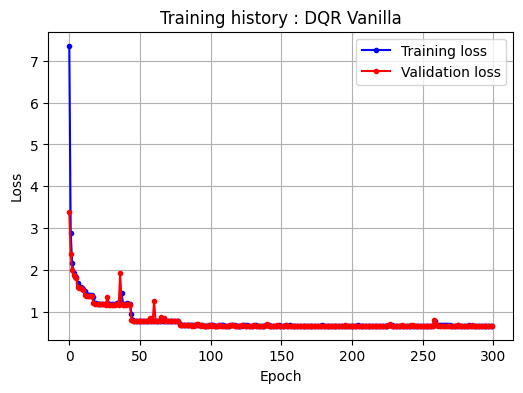

In [14]:
model_vanilla = get_or_train_model(
    f"models/{ticker}/dqr_vanilla.pt",
    data=data_vanilla,
    compute_model=False,
    use_hour=False,
    use_last_event=False)
model_vanilla.plot_history(model_name="Vanilla")

### Hour Model ###

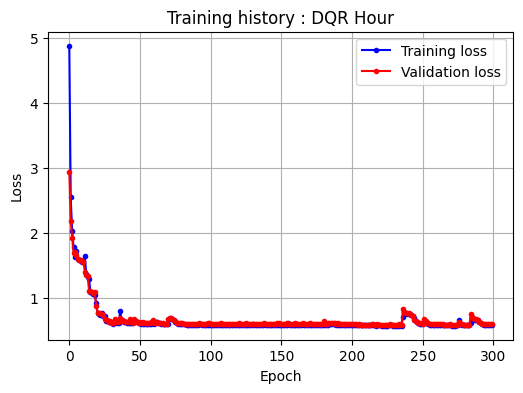

In [15]:
model_hour = get_or_train_model(
    f"models/{ticker}/dqr_hour.pt",
    data=data_hour,
    compute_model=False,
    use_hour=True,
    use_last_event=False,
    hour_num_classes=df_train["hour_last_event"].nunique())
model_hour.plot_history(model_name="Hour")

### Last-Event Model ###

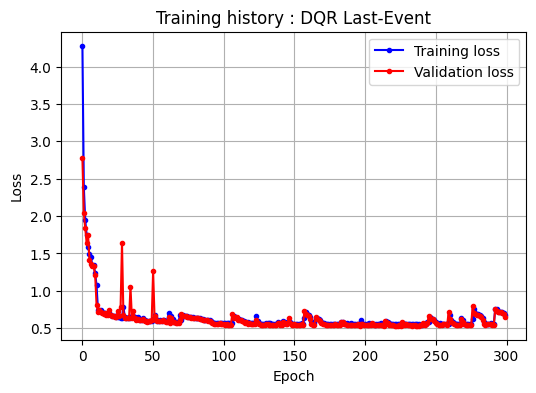

In [16]:
model_last_event = get_or_train_model(
    f"models/{ticker}/dqr_last_event.pt",
    data=data_last_event,
    compute_model=False,
    use_hour=False,
    use_last_event=True)
model_last_event.plot_history(model_name="Last-Event")

### Hour + Last-Event Model ###

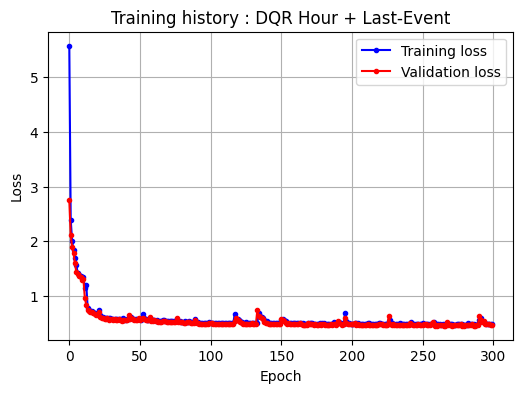

In [17]:
model_hour_last_event = get_or_train_model(
    f"models/{ticker}/dqr_hour_last_event.pt",
    data=data_hour_last_event,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=df_train["hour_last_event"].nunique())
model_hour_last_event.plot_history(model_name="Hour + Last-Event")

In [18]:
from dqrfunctions import transition_real, transition_dqr

event_id_np = df_train["event_id"].to_numpy()
last_id_np  = df_train["last_event_id"].to_numpy()
# DQR: last_event_id must match X lines format (torch)
last_id_t = torch.tensor(last_id_np, dtype=torch.long)

T_real = transition_real(event_id_np, last_id_np, n_events=3)
T_dqr_le = transition_dqr(
                        model=model_last_event,
                        data=data_last_event,
                        last_event_id=last_id_t,
                        n_events=3)
T_dqr_h_le = transition_dqr(
                        model=model_hour_last_event,
                        data=data_hour_last_event,
                        last_event_id=last_id_t,
                        n_events=3)
T_qr = qr_matrix.to_numpy()

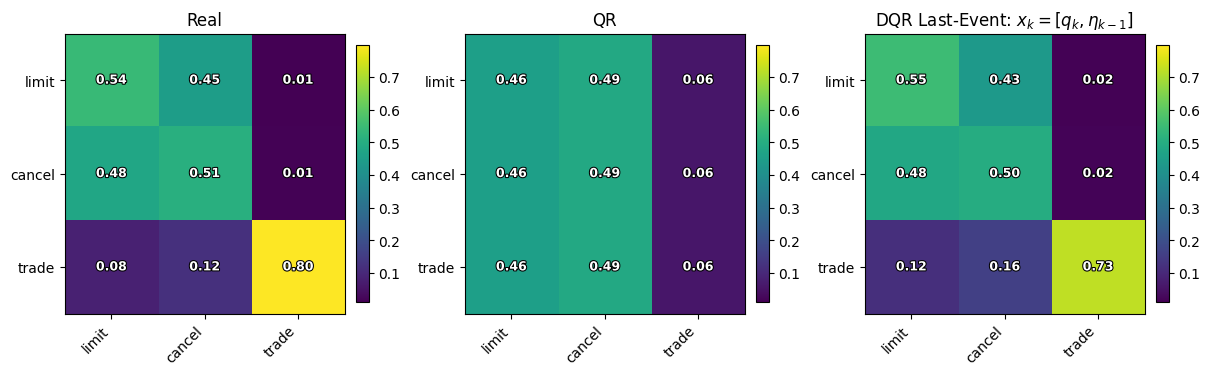

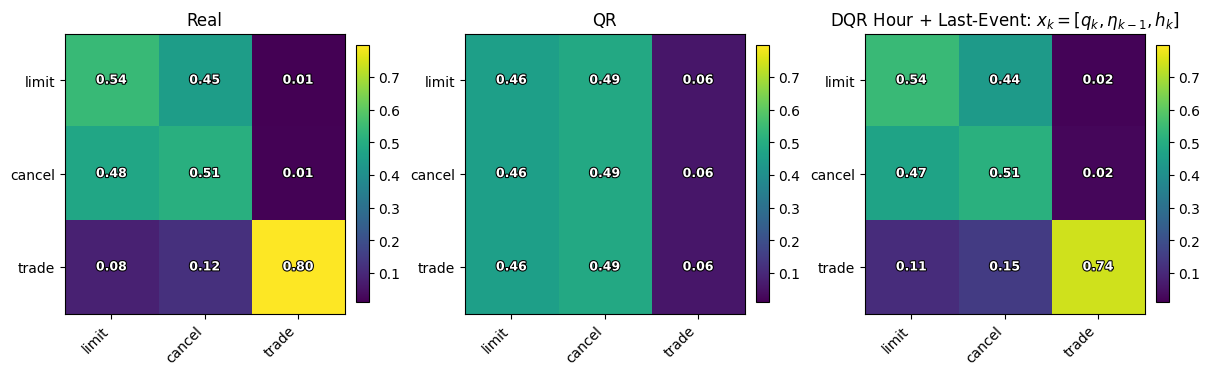

In [19]:
from dqrfunctions import plot_two_heatmaps, plot_three_heatmaps

EVENT_NAMES = ["limit", "cancel", "trade"]
dqr_last_event_title = r"DQR Last-Event: $x_k=[q_k,\eta_{k-1}]$"
dqr_hour_last_event_title = r"DQR Hour + Last-Event: $x_k=[q_k,\eta_{k-1},h_k]$"

fig = plot_three_heatmaps(T_real, T_qr, T_dqr_le, labels=EVENT_NAMES, dqr_title=dqr_last_event_title)
plt.show()
fig = plot_three_heatmaps(T_real, T_qr, T_dqr_h_le, labels=EVENT_NAMES, dqr_title=dqr_hour_last_event_title)
plt.show()

In [20]:
from dqrfunctions import compute_hourly_intensity, compute_real_hourly_intensity
hourly_dqr_h = compute_hourly_intensity(model_hour, data_hour, df_train["hour_last_event"].values)
hourly_dqr_h_le = compute_hourly_intensity(model_hour_last_event, data_hour_last_event, df_train["hour_last_event"].values)
hourly_real = compute_real_hourly_intensity(df_train, trade_id=2)

from qrFunctions import compute_hourly_intensity_qr
hourly_qr, constant_hourly_qr = compute_hourly_intensity_qr(lambdas, df_train)

In [25]:
constant_hourly_qr

np.float64(0.14698427526612381)

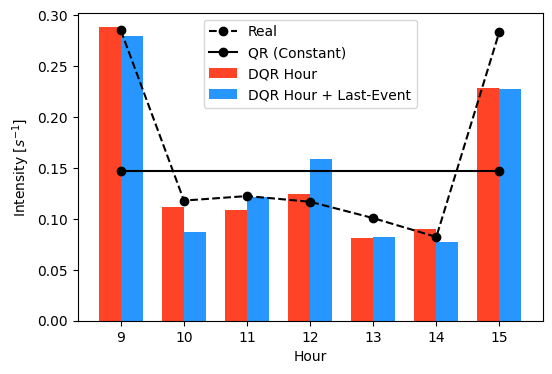

In [32]:
width = 0.35
x = hourly_dqr_h.index.values + 9
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(x - width/2, hourly_dqr_h.values, width=width, color="#FF4327", label="DQR Hour")
ax.bar(x + width/2, hourly_dqr_h_le.values, width=width, color="#2797FF", label="DQR Hour + Last-Event")
ax.plot(x, hourly_real.values, "o--", color="black", label="Real")
#ax.plot(hourly_qr.index, hourly_qr.values, label="QR", marker='^', linestyle='--', color='darkblue')
ax.plot([x.min(), x.max()], [constant_hourly_qr, constant_hourly_qr], 'o-', color='black', label='QR (Constant)')
ax.set_xlabel("Hour")
ax.set_ylabel(r"Intensity [$s^{-1}$]")
ax.set_xticks(x)
ax.legend()
plt.show()

# EN TRAVAUX #

In [22]:
from dqrfunctions import evaluate_dqr_model, plot_model_comparison

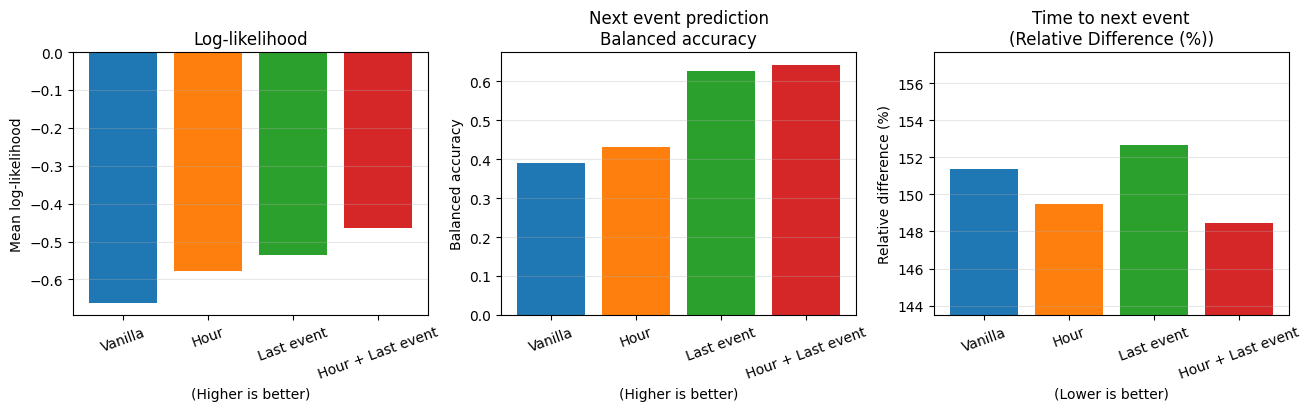

In [23]:
results = {
    "Vanilla": evaluate_dqr_model(model_vanilla, data_vanilla),
    "Hour": evaluate_dqr_model(model_hour, data_hour),
    "Last event": evaluate_dqr_model(model_last_event, data_last_event),
    "Hour + Last event": evaluate_dqr_model(model_hour_last_event, data_hour_last_event),
}
plot_model_comparison(results)